# End-to-End E-Commerce Sales Analytics Project

**Business question:** Where is revenue coming from, which categories/products drive it, how profitable is each part of the business, and how healthy is customer retention?

**What this project demonstrates**
- Loading a real-world dataset via `kagglehub`
- Data validation & cleaning (type fixes, integrity checks, a real data-quality bug)
- SQL analysis (via SQLite) — joins, aggregations, window functions
- KPI calculation (revenue, AOV, profit margin, repeat purchase rate)
- Profitability analysis (discount impact, loss-making sub-categories)
- Cohort retention analysis
- Data visualization for stakeholder-ready insights
- A written recommendation section grounded in the actual numbers

**Tools:** pandas, numpy, sqlite3, matplotlib, seaborn, kagglehub

**Dataset:** [Superstore Dataset (Final)](https://www.kaggle.com/datasets/vivek468/superstore-dataset-final) on Kaggle — ~9,994 order line items from a US office-supply retailer (2014–2017), with customers, products, regions, sales, discounts and profit.


In [2]:
!pip install kagglehub


   ---------------------------------------- 0/2 [kagglesdk]
   ---------------------------------------- 0/2 [kagglesdk]
   ---------------------------------------- 0/2 [kagglesdk]
   -------------------- ------------------- 1/2 [kagglehub]
   ---------------------------------------- 2/2 [kagglehub]



In [1]:
import kagglehub
import os
import numpy as np
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

## 1. Load the dataset

Downloaded directly from Kaggle via `kagglehub` — no manual upload needed. `kagglehub` caches the files locally and returns the path to the folder containing the CSV.


In [2]:
# Download latest version
path = kagglehub.dataset_download("vivek468/superstore-dataset-final")
print("Path to dataset files:", path)

Path to dataset files: C:\Users\Adhiya\.cache\kagglehub\datasets\vivek468\superstore-dataset-final\versions\1


In [3]:
csv_file = [f for f in os.listdir(path) if f.endswith(".csv")][0]
df = pd.read_csv(os.path.join(path, csv_file), encoding="latin1")

print(f"Loaded {df.shape[0]:,} rows, {df.shape[1]} columns")
df.head()

Loaded 9,994 rows, 21 columns


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.96,2,0.00,41.91
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.94,3,0.00,219.58
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.62,2,0.00,6.87
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.58,5,0.45,-383.03
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.37,2,0.20,2.52


## 2. Data cleaning & validation

Standardize column names/types, check for the usual failure modes (nulls, duplicates, bad dates, inconsistent categories), and validate business logic. One real data-quality bug does turn up: US postal codes get stored as integers, which silently drops the leading zero on New England ZIP codes (e.g. `02138` becomes `2138`).


In [4]:
# --- Standardize column names to snake_case ---
df.columns = [c.strip().lower().replace(" ", "_").replace("-", "_") for c in df.columns]
print(df.columns.tolist())

['row_id', 'order_id', 'order_date', 'ship_date', 'ship_mode', 'customer_id', 'customer_name', 'segment', 'country', 'city', 'state', 'postal_code', 'region', 'product_id', 'category', 'sub_category', 'product_name', 'sales', 'quantity', 'discount', 'profit']


In [5]:
# --- Missing values ---
print("Missing values per column:")
print(df.isna().sum()[df.isna().sum() > 0] if df.isna().sum().sum() else "None found.")

# --- Exact duplicate rows ---
n_dupes = df.duplicated().sum()
print(f"\nExact duplicate rows: {n_dupes}")

# --- Parse dates and validate ---
df["order_date"] = pd.to_datetime(df["order_date"], format="%m/%d/%Y")
df["ship_date"] = pd.to_datetime(df["ship_date"], format="%m/%d/%Y")
bad_ship = (df["ship_date"] < df["order_date"]).sum()
print(f"Orders shipped before they were placed (data integrity check): {bad_ship}")
print(f"Order date range: {df['order_date'].min().date()} to {df['order_date'].max().date()}")

# --- Category / segment / region label consistency ---
for col in ["category", "sub_category", "segment", "region", "ship_mode"]:
    print(f"{col}: {sorted(df[col].unique())}")

Missing values per column:
None found.

Exact duplicate rows: 0
Orders shipped before they were placed (data integrity check): 0
Order date range: 2014-01-03 to 2017-12-30
category: ['Furniture', 'Office Supplies', 'Technology']
sub_category: ['Accessories', 'Appliances', 'Art', 'Binders', 'Bookcases', 'Chairs', 'Copiers', 'Envelopes', 'Fasteners', 'Furnishings', 'Labels', 'Machines', 'Paper', 'Phones', 'Storage', 'Supplies', 'Tables']
segment: ['Consumer', 'Corporate', 'Home Office']
region: ['Central', 'East', 'South', 'West']
ship_mode: ['First Class', 'Same Day', 'Second Class', 'Standard Class']


In [6]:
# --- Real bug: postal codes stored as int lose the leading zero on New England ZIPs ---
short_zips = (df["postal_code"] < 10000).sum()
print(f"Postal codes that lost a leading zero as integers: {short_zips}")

df["postal_code"] = df["postal_code"].astype(str).str.zfill(5)
print("Fixed — example:", df.loc[df["state"] == "Vermont", "postal_code"].unique())

Postal codes that lost a leading zero as integers: 449
Fixed — example: ['05408']


In [7]:
# --- Line items sharing the same order + product (not exact dupes — different qty/discount) ---
dup_line_items = df.duplicated(subset=["order_id", "product_id"], keep=False).sum()
print(f"Order+product combinations appearing more than once (split line items, not errors): {dup_line_items}")

# revenue = 'sales' in the source data; keep the original column name, no unit changes needed
print("\nNumeric summary:")
df[["sales", "quantity", "discount", "profit"]].describe()

Order+product combinations appearing more than once (split line items, not errors): 16

Numeric summary:


,sales,quantity,discount,profit
count,"9,994.00","9,994.00","9,994.00","9,994.00"
mean,229.86,3.79,0.16,28.66
std,623.25,2.23,0.21,234.26
min,0.44,1.00,0.00,"-6,599.98"
25%,17.28,2.00,0.00,1.73
50%,54.49,3.00,0.20,8.67
75%,209.94,5.00,0.20,29.36
max,"22,638.48",14.00,0.80,"8,399.98"


## 3. Load into SQLite and run SQL analysis

Loading the cleaned table into an actual SQL database so the analysis uses real SQL (joins, `GROUP BY`, `CASE`, window functions).


In [8]:
conn = sqlite3.connect(":memory:")
df.to_sql("orders", conn, index=False, if_exists="replace")

def q(sql):
    return pd.read_sql_query(sql, conn)

### 3.1 Headline KPIs

In [9]:
kpis = q('''
SELECT
    ROUND(SUM(sales), 2)                                   AS total_revenue,
    COUNT(DISTINCT order_id)                                AS total_orders,
    COUNT(DISTINCT customer_id)                              AS unique_customers,
    ROUND(SUM(sales) * 1.0 / COUNT(DISTINCT order_id), 2)     AS avg_order_value,
    ROUND(SUM(profit), 2)                                     AS total_profit,
    ROUND(SUM(profit) * 100.0 / SUM(sales), 2)                 AS profit_margin_pct
FROM orders
''')
kpis

,total_revenue,total_orders,unique_customers,avg_order_value,total_profit,profit_margin_pct
0,"2,297,200.86",5009,793,458.61,"286,397.02",12.47


### 3.2 Monthly revenue trend & year-over-year growth

In [10]:
monthly_revenue = q('''
SELECT
    strftime('%Y-%m', order_date) AS month,
    ROUND(SUM(sales), 2) AS revenue,
    COUNT(DISTINCT order_id) AS orders
FROM orders
GROUP BY month
ORDER BY month
''')

yearly = q('''
SELECT
    strftime('%Y', order_date) AS year,
    ROUND(SUM(sales), 2) AS revenue,
    ROUND(SUM(profit), 2) AS profit
FROM orders
GROUP BY year
''')
yearly["yoy_growth_pct"] = (yearly["revenue"].pct_change() * 100).round(2)
yearly

,year,revenue,profit,yoy_growth_pct
0,2014,"484,247.50","49,543.97",NaN
1,2015,"470,532.51","61,618.60",-2.83
2,2016,"609,205.60","81,795.17",29.47
3,2017,"733,215.26","93,439.27",20.36


### 3.3 Category & sub-category performance (revenue *and* profit)

Revenue alone hides the story here — some sub-categories are losing money outright.


In [11]:
category_perf = q('''
SELECT
    category,
    ROUND(SUM(sales), 2) AS revenue,
    ROUND(SUM(profit), 2) AS profit,
    ROUND(SUM(profit) * 100.0 / SUM(sales), 2) AS margin_pct
FROM orders
GROUP BY category
ORDER BY revenue DESC
''')
category_perf

,category,revenue,profit,margin_pct
0,Technology,"836,154.03","145,454.95",17.40
1,Furniture,"741,999.80","18,451.27",2.49
2,Office Supplies,"719,047.03","122,490.80",17.04


In [12]:
subcategory_perf = q('''
SELECT
    category,
    sub_category,
    ROUND(SUM(sales), 2) AS revenue,
    ROUND(SUM(profit), 2) AS profit,
    ROUND(SUM(profit) * 100.0 / SUM(sales), 2) AS margin_pct
FROM orders
GROUP BY category, sub_category
ORDER BY profit ASC
''')

print("Loss-making sub-categories:")
subcategory_perf.head(5)

Loss-making sub-categories:


,category,sub_category,revenue,profit,margin_pct
0,Furniture,Tables,"206,965.53","-17,725.48",-8.56
1,Furniture,Bookcases,"114,880.00","-3,472.56",-3.02
2,Office Supplies,Supplies,"46,673.54","-1,189.10",-2.55
3,Office Supplies,Fasteners,"3,024.28",949.52,31.40
4,Technology,Machines,"189,238.63","3,384.76",1.79


### 3.4 Discount impact on profitability

Splitting order lines into discount bands to see whether heavier discounting is actually paying for itself.


In [13]:
discount_impact = q('''
SELECT
    CASE
        WHEN discount = 0 THEN '1. No discount'
        WHEN discount <= 0.2 THEN '2. Low (<=20%)'
        ELSE '3. High (>20%)'
    END AS discount_band,
    COUNT(*) AS line_items,
    ROUND(SUM(sales), 2) AS revenue,
    ROUND(SUM(profit), 2) AS total_profit,
    ROUND(AVG(profit), 2) AS avg_profit_per_line
FROM orders
GROUP BY discount_band
ORDER BY discount_band
''')
discount_impact

,discount_band,line_items,revenue,total_profit,avg_profit_per_line
0,1. No discount,4798,"1,087,908.47","320,987.60",66.90
1,2. Low (<=20%),3803,"846,522.24","100,785.47",26.50
2,3. High (>20%),1393,"362,770.15","-135,376.06",-97.18


### 3.5 Regional & segment performance

In [14]:
region_perf = q('''
SELECT region, ROUND(SUM(sales),2) AS revenue, ROUND(SUM(profit),2) AS profit,
       ROUND(SUM(profit)*100.0/SUM(sales),2) AS margin_pct
FROM orders GROUP BY region ORDER BY revenue DESC
''')

segment_perf = q('''
SELECT segment, ROUND(SUM(sales),2) AS revenue, ROUND(SUM(profit),2) AS profit,
       ROUND(SUM(profit)*100.0/SUM(sales),2) AS margin_pct
FROM orders GROUP BY segment ORDER BY revenue DESC
''')

print("By region:")
display(region_perf)
print("\nBy segment:")
display(segment_perf)

By region:


,region,revenue,profit,margin_pct
0,West,"725,457.82","108,418.45",14.94
1,East,"678,781.24","91,522.78",13.48
2,Central,"501,239.89","39,706.36",7.92
3,South,"391,721.91","46,749.43",11.93



By segment:


,segment,revenue,profit,margin_pct
0,Consumer,"1,161,401.34","134,119.21",11.55
1,Corporate,"706,146.37","91,979.13",13.03
2,Home Office,"429,653.15","60,298.68",14.03


### 3.6 Repeat purchase rate & customer value (SQL window function)

In [15]:
customer_orders = q('''
SELECT
    customer_id,
    COUNT(DISTINCT order_id) AS num_orders,
    ROUND(SUM(sales), 2) AS lifetime_value,
    ROUND(SUM(profit), 2) AS lifetime_profit
FROM orders
GROUP BY customer_id
''')

repeat_rate = (customer_orders["num_orders"] > 1).mean()
print(f"Repeat purchase rate: {repeat_rate:.1%}")

top20_share = (
    customer_orders.sort_values("lifetime_value", ascending=False)
    .head(int(len(customer_orders) * 0.2))["lifetime_value"].sum()
    / customer_orders["lifetime_value"].sum()
)
print(f"Revenue share from top 20% of customers by LTV: {top20_share:.1%}")

# Rank customers by lifetime value using a window function
customer_rank = q('''
SELECT
    customer_id,
    ROUND(SUM(sales), 2) AS lifetime_value,
    ROUND(SUM(profit), 2) AS lifetime_profit,
    RANK() OVER (ORDER BY SUM(sales) DESC) AS value_rank
FROM orders
GROUP BY customer_id
ORDER BY value_rank
LIMIT 10
''')
customer_rank

Repeat purchase rate: 98.5%
Revenue share from top 20% of customers by LTV: 48.0%


,customer_id,lifetime_value,lifetime_profit,value_rank
0,SM-20320,"25,043.05","-1,980.74",1
1,TC-20980,"19,052.22","8,981.32",2
2,RB-19360,"15,117.34","6,976.10",3
3,TA-21385,"14,595.62","4,703.79",4
4,AB-10105,"14,473.57","5,444.81",5
5,KL-16645,"14,175.23",806.85,6
6,SC-20095,"14,142.33","5,757.41",7
7,HL-15040,"12,873.30","5,622.43",8
8,SE-20110,"12,209.44","2,650.68",9
9,CC-12370,"12,129.07","2,177.05",10


## 4. Visualizations

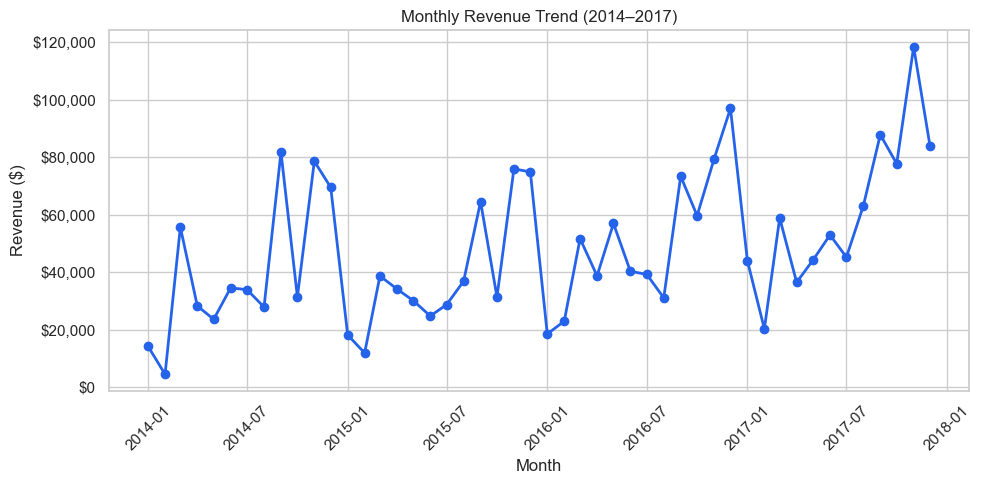

In [25]:
monthly_revenue["month"] = pd.to_datetime(monthly_revenue["month"])
fig, ax = plt.subplots()
ax.plot(monthly_revenue["month"], monthly_revenue["revenue"], marker="o", linewidth=2, color="#2563eb")
ax.set_title("Monthly Revenue Trend (2014\u20132017)")
ax.set_xlabel("Month")
ax.set_ylabel("Revenue ($)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

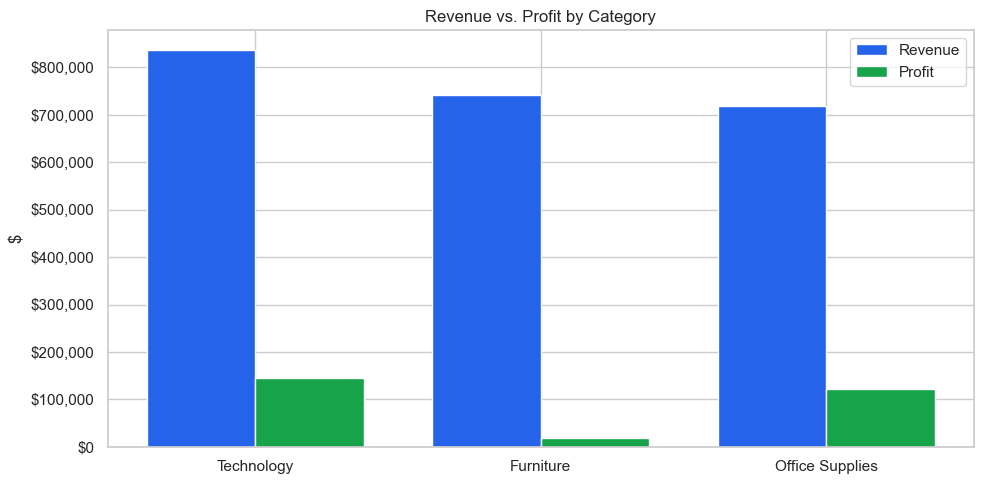

In [17]:
fig, ax = plt.subplots()
x = np.arange(len(category_perf))
width = 0.38
ax.bar(x - width/2, category_perf["revenue"], width, label="Revenue", color="#2563eb")
ax.bar(x + width/2, category_perf["profit"], width, label="Profit", color="#16a34a")
ax.set_xticks(x)
ax.set_xticklabels(category_perf["category"])
ax.set_title("Revenue vs. Profit by Category")
ax.set_ylabel("$")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))
ax.legend()
plt.tight_layout()
plt.show()

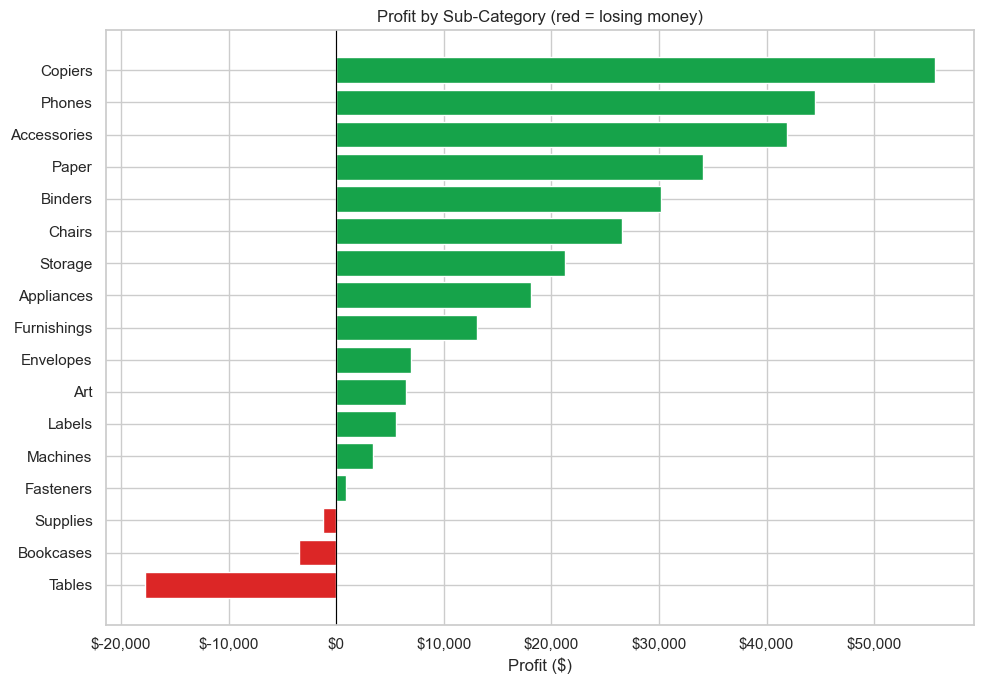

In [18]:
plot_df = subcategory_perf.sort_values("profit")
colors = ["#dc2626" if v < 0 else "#16a34a" for v in plot_df["profit"]]
fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(plot_df["sub_category"], plot_df["profit"], color=colors)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_title("Profit by Sub-Category (red = losing money)")
ax.set_xlabel("Profit ($)")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))
plt.tight_layout()
plt.show()

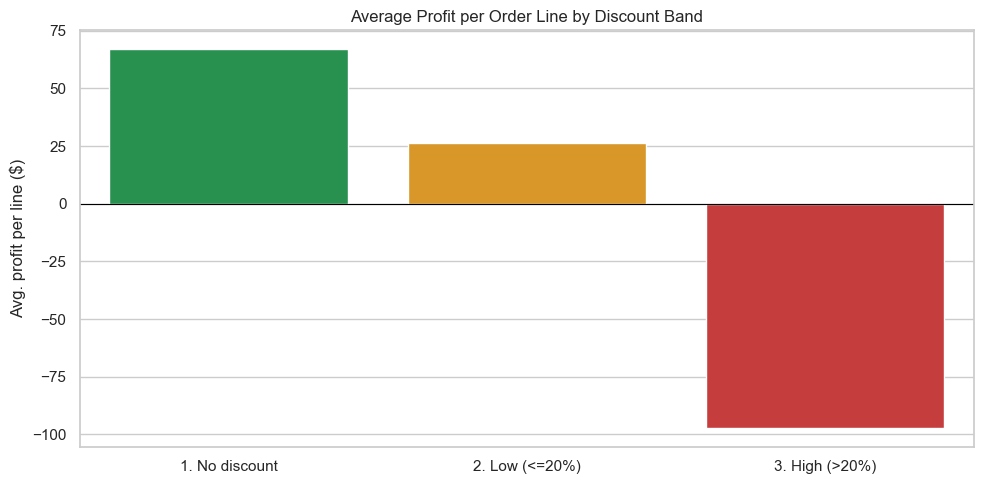

In [19]:
fig, ax = plt.subplots()
sns.barplot(data=discount_impact, x="discount_band", y="avg_profit_per_line", ax=ax,
            hue="discount_band", palette=["#16a34a", "#f59e0b", "#dc2626"], legend=False)
ax.axhline(0, color="black", linewidth=0.8)
ax.set_title("Average Profit per Order Line by Discount Band")
ax.set_xlabel("")
ax.set_ylabel("Avg. profit per line ($)")
plt.tight_layout()
plt.show()

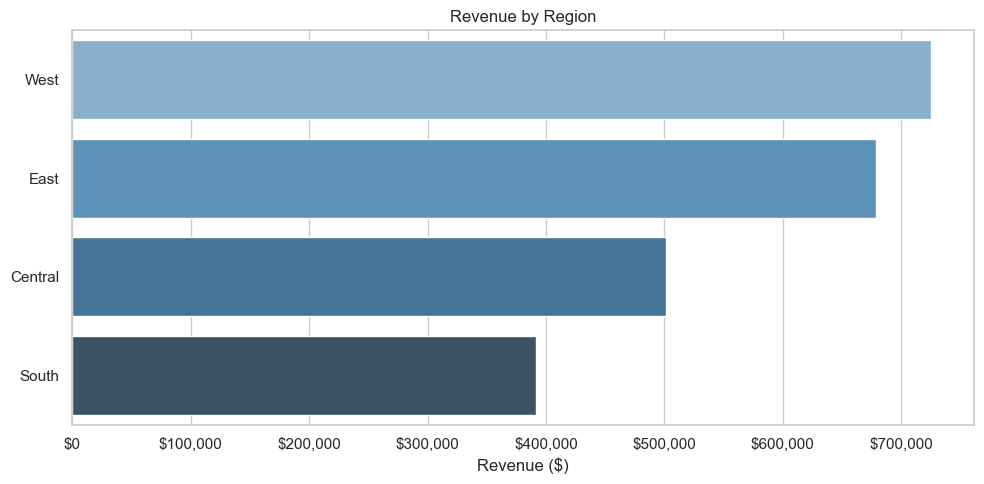

In [20]:
fig, ax = plt.subplots()
sns.barplot(data=region_perf, x="revenue", y="region", ax=ax, hue="region",
            palette="Blues_d", legend=False)
ax.set_title("Revenue by Region")
ax.set_xlabel("Revenue ($)")
ax.set_ylabel("")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))
plt.tight_layout()
plt.show()

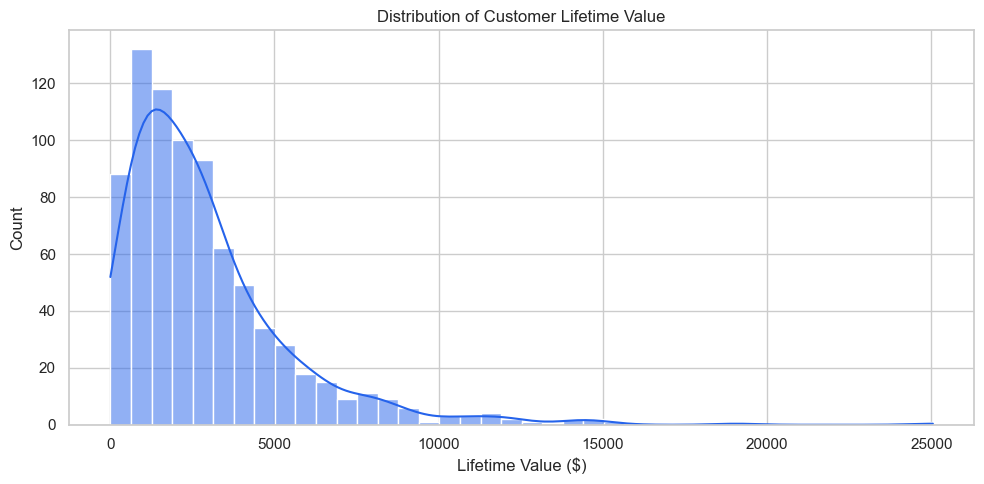

In [21]:
fig, ax = plt.subplots()
sns.histplot(customer_orders["lifetime_value"], bins=40, kde=True, ax=ax, color="#2563eb")
ax.set_title("Distribution of Customer Lifetime Value")
ax.set_xlabel("Lifetime Value ($)")
plt.tight_layout()
plt.show()

## 5. Cohort retention analysis

This dataset is B2B order history hence each customer's **first purchase month** is used as their cohort, and we track what share of each cohort places another order in each of the following months.

Note the caveat in Section 6: with only ~793 customers ordering over 4 years, purchases are naturally infrequent, so month-over-month retention reads much lower than the *overall* repeat-purchase rate — the two metrics answer different questions.


In [22]:
df["order_month"] = df["order_date"].values.astype("datetime64[M]")
first_purchase = df.groupby("customer_id")["order_month"].min().rename("cohort_month")
df = df.merge(first_purchase, on="customer_id", how="left")

df["cohort_index"] = (
    (df["order_month"].dt.year - df["cohort_month"].dt.year) * 12
    + (df["order_month"].dt.month - df["cohort_month"].dt.month)
)

cohort_pivot = (
    df[df["cohort_index"].between(0, 11)]
    .groupby(["cohort_month", "cohort_index"])["customer_id"]
    .nunique()
    .reset_index()
    .pivot(index="cohort_month", columns="cohort_index", values="customer_id")
)
# The last calendar month that actually exists in the data
DATA_CUTOFF = df["order_month"].max()

#  For every (cohort_month, cohort_index) cell, was that calendar month
#    actually within our observation window?
#    cohort_month + cohort_index months <= DATA_CUTOFF  ->  observable
observable = pd.DataFrame(
    {
        ci: (cohort_pivot.index + pd.DateOffset(months=ci)) <= DATA_CUTOFF
        for ci in cohort_pivot.columns
    },
    index=cohort_pivot.index,
)

#  Zero-fill ONLY where the period was observable but had no purchases.
#    Cells outside the observable window stay NaN ("not yet known"), not 0.
counts_filled = cohort_pivot.where(~observable, cohort_pivot.fillna(0))

#  Convert counts -> retention %
cohort_size = counts_filled[0]
retention = counts_filled.divide(cohort_size, axis=0).round(3)

# cohort_size = cohort_pivot[0]
# retention = cohort_pivot.divide(cohort_size, axis=0).round(3)
retention.index = retention.index.strftime("%Y-%m")

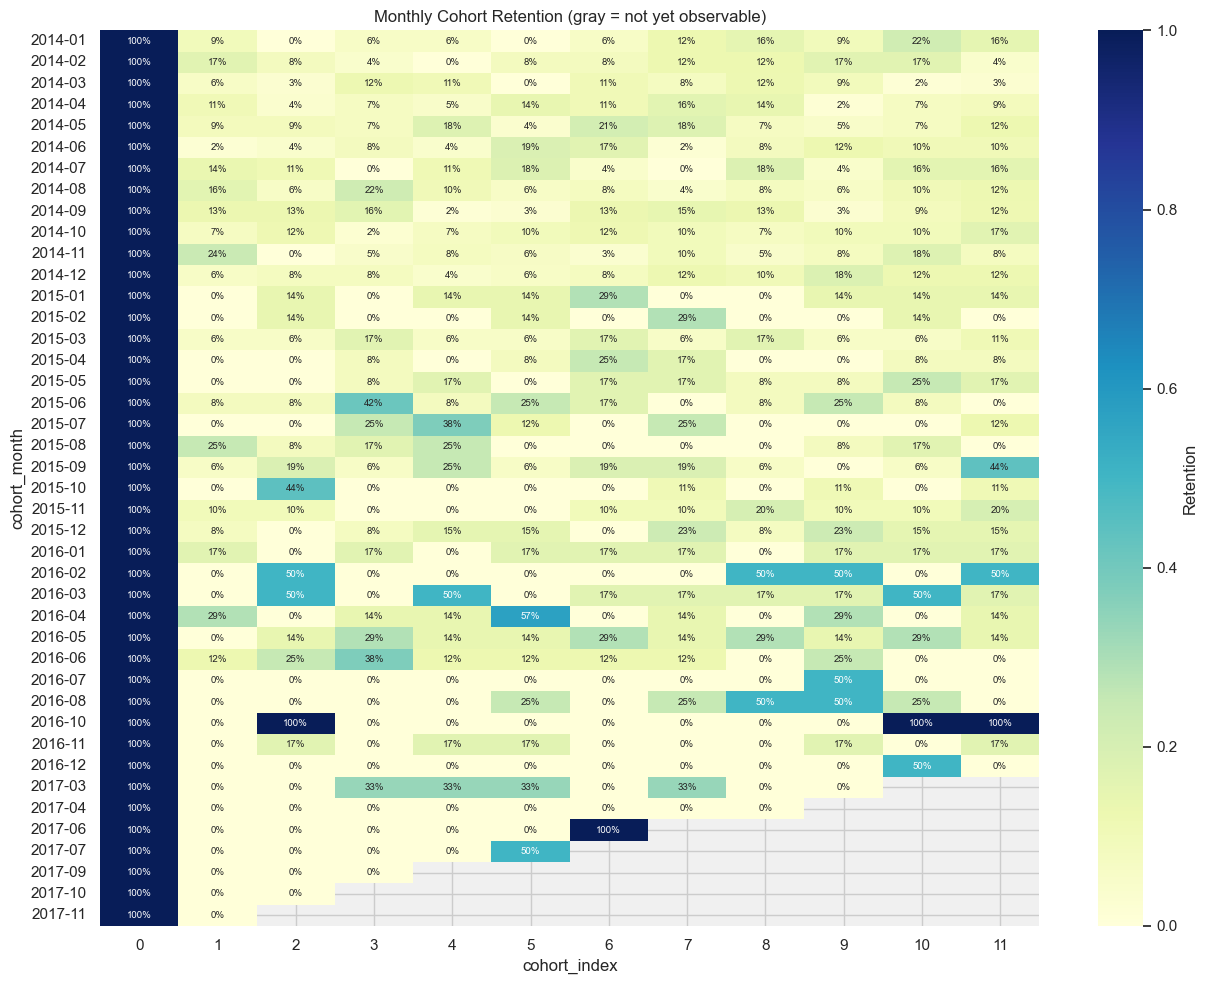

In [23]:
fig, ax = plt.subplots(figsize=(13, 10))
sns.heatmap(
    retention,
    annot=True, fmt=".0%", annot_kws={"size": 7},
    cmap="YlGnBu",
    mask=retention.isna(),          # <- NaN cells are left blank/uncolored
    cbar_kws={"label": "Retention"},
    ax=ax,
)
ax.set_facecolor("#f0f0f0")          # blank cells show as light gray, not white-empty
ax.set_title("Monthly Cohort Retention (gray = not yet observable)")
plt.tight_layout()
plt.show()

In [24]:
print(f"Average month-1 retention across cohorts: {retention[1].mean():.1%}")
print(f"Average month-3 retention across cohorts: {retention[3].mean():.1%}")
print(f"Average month-6 retention across cohorts: {retention[6].mean():.1%}")

Average month-1 retention across cohorts: 6.1%
Average month-3 retention across cohorts: 9.0%
Average month-6 retention across cohorts: 11.3%


## 6. Cohort retention analysis -2
Lets see the purchase-frequency-based retention metric instead of strict monthly cohorts.

In [26]:
# --- Purchase-frequency-based retention: "did the customer order again within N months?" ---
# This avoids the noise of strict month-by-month cohorts (which mostly captures whether
# someone happened to buy in one specific 30-day window) and instead asks the more
# business-relevant question: did they come back at all within a reasonable window.

WINDOW_MONTHS = 6

# Reuse the same first-purchase cohort_month from before
customer_first = first_purchase.reset_index()

# DATA_CUTOFF = df["order_month"].max()

# Only include customers whose cohort had FULL 6 months to prove itself
# (i.e. cohort_month + WINDOW_MONTHS <= DATA_CUTOFF) -- same masking principle as before,
# just applied once per customer instead of per grid cell.
customer_first["window_end"] = customer_first["cohort_month"] + pd.DateOffset(months=WINDOW_MONTHS)
eligible = customer_first[customer_first["window_end"] <= DATA_CUTOFF].copy()

print(f"Customers with a full {WINDOW_MONTHS}-month observation window: "
      f"{len(eligible):,} of {len(customer_first):,}")

# For each eligible customer, did they place ANY order strictly after their first
# purchase month, and on/before window_end?
def returned_within_window(row):
    cust_orders = df.loc[df["customer_id"] == row["customer_id"], "order_month"]
    return ((cust_orders > row["cohort_month"]) & (cust_orders <= row["window_end"])).any()

# Vectorized version (faster than the row-wise apply above for larger data) --------
orders_by_customer = df.groupby("customer_id")["order_month"].apply(set).rename("order_months")
eligible = eligible.merge(orders_by_customer, on="customer_id", how="left")

def returned_vectorized(row):
    return any(row["cohort_month"] < m <= row["window_end"] for m in row["order_months"])

eligible["returned"] = eligible.apply(returned_vectorized, axis=1)

overall_retention = eligible["returned"].mean()
print(f"\n{WINDOW_MONTHS}-month purchase-frequency retention (all eligible customers): "
      f"{overall_retention:.1%}")

# --- Optional: break it down by cohort month, to see the trend over time ---
retention_by_cohort = (
    eligible.groupby("cohort_month")["returned"]
    .agg(n_customers="count", retained="sum")
)
retention_by_cohort["retention_pct"] = (
    retention_by_cohort["retained"] / retention_by_cohort["n_customers"]
).round(3)

print(f"\n{WINDOW_MONTHS}-month retention by first-purchase cohort:")
retention_by_cohort

Customers with a full 6-month observation window: 787 of 793

6-month purchase-frequency retention (all eligible customers): 44.6%

6-month retention by first-purchase cohort:


,n_customers,retained,retention_pct
cohort_month,,,
2014-01-01,32,9,0.28
2014-02-01,24,9,0.38
2014-03-01,65,22,0.34
2014-04-01,56,25,0.45
2014-05-01,56,29,0.52
2014-06-01,48,21,0.44
2014-07-01,44,21,0.48
2014-08-01,49,25,0.51
2014-09-01,68,31,0.46


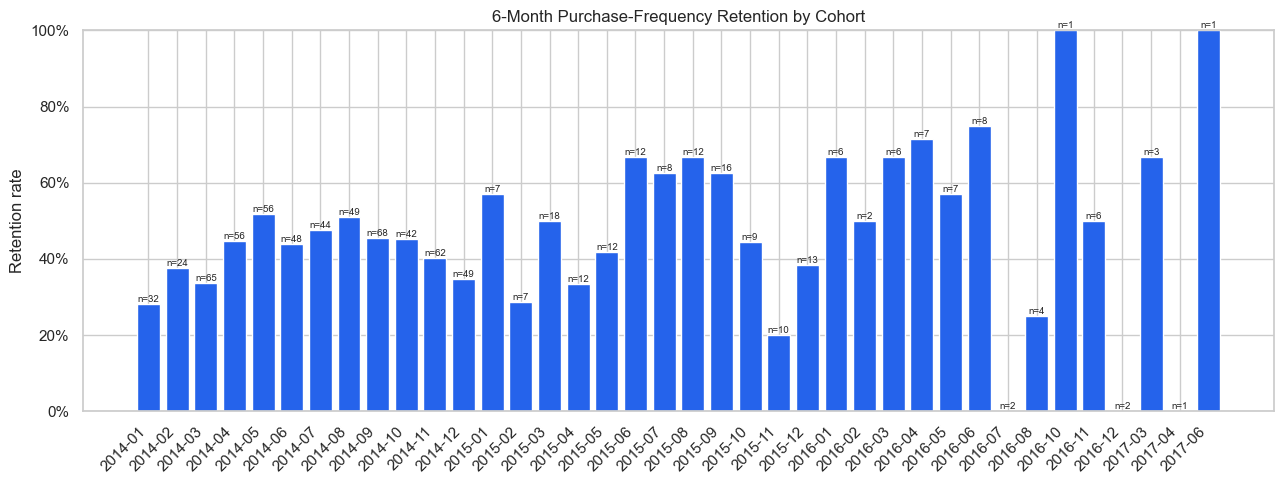

In [27]:
plot_df = retention_by_cohort.copy()
plot_df.index = plot_df.index.strftime("%Y-%m")

fig, ax = plt.subplots(figsize=(13, 5))
bars = ax.bar(plot_df.index, plot_df["retention_pct"], color="#2563eb")

# annotate each bar with n_customers, since a small cohort's % is noisier
for bar, n in zip(bars, plot_df["n_customers"]):
    ax.annotate(f"n={n}", (bar.get_x() + bar.get_width()/2, bar.get_height()),
                ha="center", va="bottom", fontsize=7)

ax.set_title(f"{WINDOW_MONTHS}-Month Purchase-Frequency Retention by Cohort")
ax.set_ylabel("Retention rate")
ax.set_ylim(0, 1)
ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## 7. Key insights & recommendations

**Revenue trend:** Revenue grew every year except a small dip in 2015 (-2.8% vs. 2014). Growth then accelerated: 2016 was up 29.5% on 2015, and 2017 was up 20.4% on 2016, closing at $733K for the year the strongest year in the dataset.

**Category mix:** Revenue is fairly evenly split across the three categories - Technology ($836K, 36%), Furniture ($742K, 32%), and Office Supplies ($719K, 31%) - but profitability is not: Technology (17.4% margin) and Office Supplies (17.0%) are healthy, while **Furniture nets only a 2.5% margin** despite being the second-largest revenue driver.

**Where the profit leak is:** Furniture's weak margin traces to two specific sub-categories that are **losing money outright** Tables (-$17,725 profit on $207K revenue −8.6% margin) and Bookcases,(- $3,473 profit, -3.0% margin). Supplies (Office Supplies category) is also slightly negative (-2.6% margin).

**Discounting is the direct cause:** Order lines with **>20% discount lose money on average** (- $97.18 profit per line, - $135K in aggregate on $363K of revenue), while lines with no discount average +$66.90 profit per line. Discount and profit are negatively correlated (r ≈ -0.22) heavier discounting is systematically eating margin, not just on Tables/Bookcases.

**Regional performance:** West ($725K revenue, $108K profit) and East ($679K, $92K) are the strongest regions both in size and margin. **Central has the weakest profit** ($40K on $501K revenue, ~7.9% margin)- well below the West/East margins in the high-teens, worth a regional discount-policy review.


**Retention:** Strict month-over-month cohort retention is low — after correctly masking out cohort/month cells that fall beyond the data's own cutoff (Dec 2017), month-1 retention averages 6.1%, rising to 9.0% by month 3 and 11.3% by month 6. But that's the wrong lens for this business: Superstore customers buy infrequently (a handful of times a year, not monthly), so requiring a repeat purchase in one specific 30-day window understates real loyalty. Using a 6-month purchase-frequency window instead — retention comes out at 44.6% (787 of 793 customers had a full 6-month window to be evaluated on).
That's a far more realistic read of how loyal this customer base actually is, and lines up much better with the 98.5% \"ever repeat\" rate than the monthly cohorts numbers do.

---

**Recommendations:**
1. **Fix Tables and Bookcases pricing/discounting.** These are structurally unprofitable — cap the maximum discount allowed on these sub-categories, or revisit unit pricing, before pushing more volume through them.
2. **Rein in the >20% discount band.** It accounts for a $135K  loss against $363K of revenue — replace blanket deep discounts with targeted, margin-aware promotions (e.g., volume-based rather than flat-percentage).
3. **Audit the Central region's discount policy.** Its margin trails West/East by roughly 5–9 points on comparable revenue — the gap looks structural rather than one-off.
4. **Review top-revenue-but-unprofitable accounts individually** (like the $25K-lifetime-value customer running at a loss) — these are prime candidates for renegotiated discount terms, not blanket "high value" treatment.
